# Label Efficient — contextual algorithm comparison

Multi-algorithm comparison on the two Label Efficient games of the code base (contextual setting), in the style of
`run_comparison_le_mod.py`, with the multi-arm PG-TS added: the classic game (Cesa-Bianchi, Lugosi & Stoltz, 2005;
globally but not locally observable) and the modified game of this fork (locally observable).

## Model

**Games** (`games.label_efficient`, `games.label_efficient_modified`).  Three actions and two outcomes.

* **Action** $a \in \{0, 1, 2\}$: $a = 0$ *queries* the label (costly, observes $y$), $a = 1$ predicts class $1$,
  $a = 2$ predicts class $0$ (no feedback).
* **Outcome** $y \in \{0, 1\}$: the class of the instance.
* **Loss** (matrix $L$) and **feedback** (matrix $H$):
$$
L^{\mathrm{LE}} = \begin{pmatrix} 1 & 1 \\ 1 & 0 \\ 0 & 1 \end{pmatrix}, \qquad
L^{\mathrm{LE\text{-}mod}} = \begin{pmatrix} 0.4 & 0.4 \\ 1 & 0 \\ 0 & 1 \end{pmatrix}, \qquad
H = \begin{pmatrix} 0 & 1 \\ 2 & 2 \\ 3 & 3 \end{pmatrix}, \qquad
\ell(a, y) = L_{a,y}, \quad r(a, y) = -\ell(a, y),
$$
  i.e. only the query action reveals $y$ (signal matrix $S_0 = I_2$), the two prediction actions give constant signals.
  In the classic game the query action is dominated: $\mathcal{N} = \{(1, 2)\}$ and the loss difference of the
  neighbours must be observed through $a = 0$, which is not a neighbour (globally observable only, minimax regret
  $\Theta(T^{2/3})$).  In the modified game the query loss $0.4$ makes $a = 0$ Pareto optimal and central:
  $\mathcal{N} = \{(0, 1), (0, 2)\}$ (locally observable).

**Context and outcome model** (`synthetic_data.LinearContexts`, as in `run_comparison_at_v2.py`).  At each round the
raw features are $u_t \sim \mathrm{Unif}([0,1]^d)$ with $d = 10$; the algorithms receive the standardised context
$x_t = (u_t - \mu)/\sigma \in \mathbb{R}^d$.  The score is $s_t = w^\top u_t \in [0,1]$ with
$w \propto \mathrm{Unif}([0, 0.1]^{10})$ normalised to sum one (NumPy seed 1), and the conditional outcome distribution is
$$
q_t \;=\; \big(\Pr(y_t = 0 \mid x_t),\ \Pr(y_t = 1 \mid x_t)\big) \;=\; (s_t,\ 1 - s_t).
$$

**Protocol** (`evaluation_contextual.Evaluation_contextual`, as in the runner scripts).  The outcome is the deterministic
label $y_t = \mathbb{1}\{s_t \ge 1/2\}$, the learner plays $a_t$, observes the feedback $h(a_t, y_t)$, and the reported
quantity is the cumulative regret
$$
R_T \;=\; \sum_{t=1}^{T} \Big[\, \ell(a_t, y_t) \;-\; \min_{a}\, \ell(a, y_t) \Big].
$$

**Algorithms** (all from the code base, hyper-parameters of `run_comparison_le_mod.py`).  PGTS and STAP-Helmbolt are
two-action implementations and are excluded, as in that script.
  - Random           — uniform baseline
  - PGTS-multi       — multi-arm PG-TS (`PGTS_multiarm.PGTSMultiArm`): logistic model of the label revealed by the
                       query action, Thompson draw, $\hat q_t$, action $= \arg\min_a (L \hat q_t)_a$
  - CBPside          — Confidence Bounds for PM (deterministic)
  - RandCBPside      — Confidence Bounds for PM (randomized)
  - SquareCB.PMSide  — IGW + water-transfer (this work); water transfer on (three actions), as in the runner

Output (in `RESULTS_DIR`):
  - `comparison_le_results.npy`   (dict of {game: {name: (N_SEEDS, HORIZON) array}})
  - `comparison_le_regret.png`    (one panel per game)


In [1]:
import os
import io
import contextlib
import numpy as np
import matplotlib.pyplot as plt

from games import label_efficient, label_efficient_modified
from synthetic_data import LinearContexts
from evaluation_contextual import Evaluation_contextual
from squarecb_pmside import SquareCBPMSide
from PGTS_multiarm import PGTSMultiArm
from random_algo import Random
from cbpside import CBPside
from randcbpside import RandCPBside

In [2]:
# ── Experiment settings ────────────────────────────────────────────────────────
HORIZON = 3000
N_SEEDS = 5
D       = 10         # context dimension — must be >= 5 for CBPside/RandCBPside
GAMMA   = 1.0        # SquareCB.PMSide: effective rate gamma_t = GAMMA * sqrt(t)
LBD     = 0.05       # ridge regularisation (all ridge-regression algorithms)
ALPHA   = 1.01       # CBPside / RandCBPside confidence-bound exponent

# 10-dim weight vector matching the notebook setup (seed 1)
np.random.seed(1)
W = np.random.uniform(0, 0.1, D)
W = W / W.sum()

# RandCBPside-specific
SIGMA   = 5          # bandwidth for the randomised confidence level
K       = 10         # number of quantisation levels
EPSILON = 10e-7      # exploration probability floor

RESULTS_DIR = "results"   # where the raw results and the plot are saved

GAME_LIST = [
    ("Label Efficient",            label_efficient),            # globally observable only
    ("Label Efficient (modified)", label_efficient_modified),   # locally observable
]

In [3]:
# ── Algorithm registry ────────────────────────────────────────────────────────
# Each entry: (display_name, factory_fn)
# factory_fn() returns a fresh algorithm instance.
def make_algos(game):
    return [
        ("Random",
         lambda: Random(game, HORIZON)),

        ("PGTS-multi",
         lambda: PGTSMultiArm(game, D)),

        ("CBPside",
         lambda: CBPside(game, D, ALPHA, LBD)),

        ("RandCBPside",
         lambda: RandCPBside(game, D, ALPHA, LBD, SIGMA, K, EPSILON)),

        ("SquareCB.PMSide",
         lambda: SquareCBPMSide(game, d=D, gamma=GAMMA, lbd=LBD,
                                use_water_transfer=True)),   # BFS tree, not star
    ]

In [4]:
# ── Run all algorithms for every game ─────────────────────────────────────────
all_results = {}

for game_name, make_game in GAME_LIST:
    with contextlib.redirect_stdout(io.StringIO()):
        game        = make_game()
        context_gen = LinearContexts(W)
    evaluator = Evaluation_contextual(HORIZON)
    print(f"\n=== {game_name}: loss matrix {game.LossMatrix.tolist()}  |  neighbouring pairs {game.mathcal_N} ===")

    results = {}
    for name, factory in make_algos(game):
        runs = []
        print(f"\nRunning {name}", end="", flush=True)

        for seed in range(N_SEEDS):
            # Suppress the verbose per-step prints from evaluation_contextual and the
            # algorithms (and the Gurobi messages of CBPside's constructor) so the
            # output stays readable.
            with contextlib.redirect_stdout(io.StringIO()):
                alg = factory()
                # reset() initialises contexts for algorithms that don't do it in __init__
                # (e.g. STAP_Helmbolt, RandCBPside).  Safe to call on all algorithms.
                alg.reset()
                cr = evaluator.eval_policy_once(alg, game, job=(context_gen, seed))

            runs.append(cr)
            print(f" {seed}", end="", flush=True)

        runs = np.array(runs)   # shape (N_SEEDS, HORIZON)
        results[name] = runs
        mean_final = runs.mean(axis=0)[-1]
        print(f"  |  mean cumulative regret @ T={HORIZON}: {mean_final:.2f}")

    all_results[game_name] = results


=== Label Efficient: loss matrix [[1, 1], [1, 0], [0, 1]]  |  neighbouring pairs [[1, 2]] ===

Running Random

 0

 1

 2

 3

...

 1

 2

 3

 4

  |  mean cumulative regret @ T=3000: 213.92


In [5]:
# ── Save raw results ───────────────────────────────────────────────────────────
os.makedirs(RESULTS_DIR, exist_ok=True)
np.save(os.path.join(RESULTS_DIR, "comparison_le_results.npy"), all_results)
print(f"Raw results saved to {RESULTS_DIR}/comparison_le_results.npy")

Raw results saved to results/comparison_le_results.npy


Plot saved to results/comparison_le_regret.png


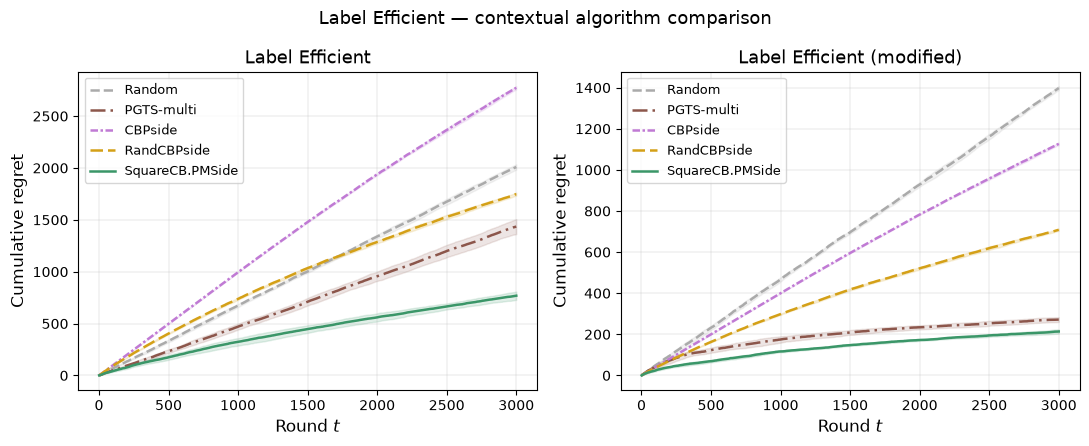

In [6]:
# ── Plot (one panel per game) ──────────────────────────────────────────────────
t      = np.arange(1, HORIZON + 1)
COLORS = {
    "Random":          "#aaaaaa",
    "PGTS":            "#e07b54",
    "PGTS-multi":      "#8c564b",
    "STAP-Helmbolt":   "#5b8db8",
    "CBPside":         "#c07ad4",
    "RandCBPside":     "#d4a017",
    "SquareCB.PMSide": "#3a9668",
}
STYLES = {
    "Random":          "--",
    "PGTS":            "-.",
    "PGTS-multi":      (0, (6, 2, 1, 2)),    # long dash-dot
    "STAP-Helmbolt":   ":",
    "CBPside":         (0, (3, 1, 1, 1)),   # dash-dot-dot
    "RandCBPside":     (0, (5, 2)),          # loose dash
    "SquareCB.PMSide": "-",
}

fig, axes = plt.subplots(1, len(GAME_LIST), figsize=(5.5 * len(GAME_LIST), 4.5), squeeze=False)

for ax, (game_name, _) in zip(axes[0], GAME_LIST):
    for name, runs in all_results[game_name].items():
        mean  = runs.mean(axis=0)
        std   = runs.std(axis=0)
        color = COLORS[name]
        ls    = STYLES[name]
        ax.plot(t, mean, label=name, color=color, linewidth=1.8, linestyle=ls)
        ax.fill_between(t, mean - std, mean + std, alpha=0.15, color=color)

    ax.set_xlabel("Round $t$", fontsize=12)
    ax.set_ylabel("Cumulative regret", fontsize=12)
    ax.set_title(game_name, fontsize=13)
    ax.legend(fontsize=9)
    ax.grid(True, linewidth=0.35, alpha=0.6)

fig.suptitle("Label Efficient — contextual algorithm comparison", fontsize=13)
fig.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "comparison_le_regret.png"), dpi=150)
print(f"Plot saved to {RESULTS_DIR}/comparison_le_regret.png")